In [2]:
library(ggplot2)
library(dplyr)
library(tidyr)
library(stringr)

Warning message:
“package ‘dplyr’ was built under R version 4.3.2”

Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Warning message:
“package ‘stringr’ was built under R version 4.3.2”


In [3]:
LDSC.res.dir <- '/nfs/lab/tscc/welison/FNIH.Liver/LDSC/'

In [4]:
# Cell type colors (middle brightness)
celltype_colors <- c(
  NK = "#6A0DAD",          # Medium Purple
  T = "#9B59B6",           # Light Purple
  Endothelial = "#E41A1C", # Medium Red
  Myeloid = "#FF7F00",     # Medium Orange
  B = "#8A2BE2",           # Medium Purple
  Cholangiocyte = "#FFD92F",# Choral
  HSC = "#1E90FF",         # Blue
  Mast = "#8B4513",        # Medium Yellow
  Schwann = "#808080",     # Grey
  Hepatocytes = "#4DAF4A"  # Medium Green
)

# Cell subtype colors (distinct shades)
cellsubtype_colors <- c(
  NK = "#6A0DAD",                                      # Medium Purple
  T = "#9B59B6",                                       # Light Purple
  Sinusoidal.Endothelial = "#D3372E",                  # Dark Red
  Lymphatic.Endothelial = "#FFCCBC",                   # Light Red
  Central.Vein.Endothelial = "#E46F69",                # Light Red
  Vascular.Endothelial = "#B22222",                    # Pale Red 
  Kupffer = "#CC4C02",                                 # Dark Orange
  Macrophage = "#FF7F00",                              # Orange
  Lipid.Associated.Macrophage = "#FC8D59",             # Light Orange
  B = "#8A2BE2",                                       # Medium Purple
  Plasma = "#BA55D3",                                  # Distinct Purple
  Cholangiocyte = "#FFD92F",                           # Choral
  Quescent.HSC = "#4682B4",                            # Steel Blue
  Activated.HSC = "#1E90FF",                           # Blue
  Mesenchymal = "#000080",                             # Navy
  Mast = "#8B4513",                                    # Medium Yellow
  Schwann = "#808080",                                 # Grey
  Hepatocytes.Zone1 = "#006D2C",                       # Dark Green
  Hepatocytes.Zone2 = "#4DAF4A",                       # Green
  Hepatocytes.Zone3 = "#78C679",                       # Light Green
  Hepatocytes.Senescent = "#A6D96A",                   # Pale Green
  Hepatocytes.Stress = "#D9F0A3"                       # Very Pale Green
)


# H2cts for the 86 map - new GWAS

In [5]:
h2s.86 <- read.table(paste0(LDSC.res.dir, 'debug/NEW.ALT.GWAS.h2cts.ophelia.86pool.hg19.pipeline.cell_type_results.txt'), header=T)
h2s.86$fdr <- p.adjust(h2s.86$Coefficient_P_value, method='fdr')
h2s.86$Name <- factor(h2s.86$Name, levels = rev(h2s.86$Name))

h2s.86

Name,Coefficient,Coefficient_std_error,Coefficient_P_value,fdr
<fct>,<dbl>,<dbl>,<dbl>,<dbl>
Hepatocytes,1.013750e-07,2.762230e-08,0.0001212552,0.001212552
Cholangiocyte,9.774705e-08,4.446504e-08,0.0139642292,0.069821146
Mast,3.296342e-08,1.026747e-07,0.3740873231,0.838259048
Schwann,1.508612e-08,8.212866e-08,0.4271287739,0.838259048
B,5.216315e-09,4.304368e-08,0.4517716422,0.838259048
Endothelial,-2.118223e-10,2.859284e-08,0.5029554290,0.838259048
Myeloid,-2.361981e-08,2.729818e-08,0.8065498306,0.908861545
NK,-4.001043e-08,4.558746e-08,0.8099366874,0.908861545
HSC,-3.162601e-08,3.484283e-08,0.8179753907,0.908861545


In [6]:
h2s.86 <- h2s.86 %>%
    mutate(
        label = case_when(
            fdr > 0.05 ~ "",
            fdr > 0.01 ~ "*",
            fdr > 0.001 ~ "**",
            !is.na(fdr) ~ "***",
            TRUE ~ NA_character_
        )
    )

h2s.86

Name,Coefficient,Coefficient_std_error,Coefficient_P_value,fdr,label
<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
Hepatocytes,1.013750e-07,2.762230e-08,0.0001212552,0.001212552,**
Cholangiocyte,9.774705e-08,4.446504e-08,0.0139642292,0.069821146,
Mast,3.296342e-08,1.026747e-07,0.3740873231,0.838259048,
Schwann,1.508612e-08,8.212866e-08,0.4271287739,0.838259048,
B,5.216315e-09,4.304368e-08,0.4517716422,0.838259048,
Endothelial,-2.118223e-10,2.859284e-08,0.5029554290,0.838259048,
Myeloid,-2.361981e-08,2.729818e-08,0.8065498306,0.908861545,
NK,-4.001043e-08,4.558746e-08,0.8099366874,0.908861545,
HSC,-3.162601e-08,3.484283e-08,0.8179753907,0.908861545,


Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


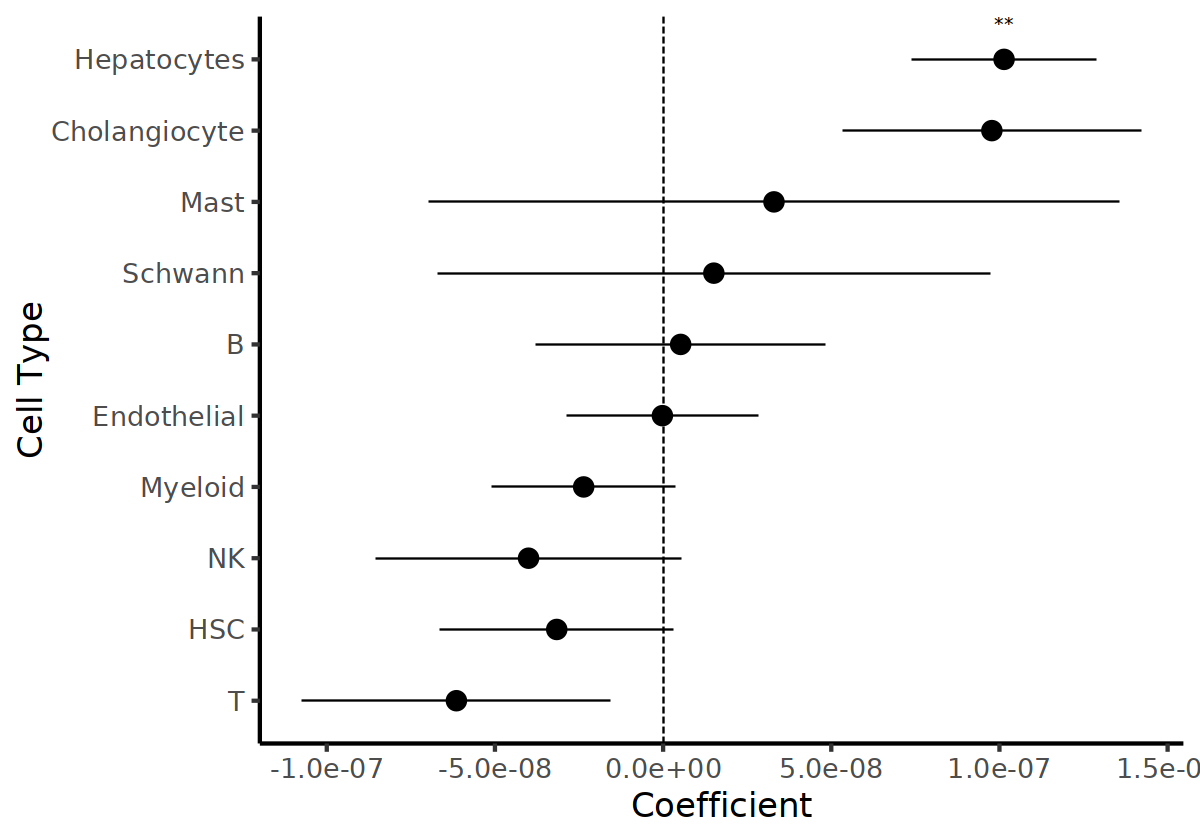

In [7]:
options(repr.plot.width=10)
p1 <- ggplot(h2s.86, aes(x=Name, y=Coefficient, ymin=Coefficient-Coefficient_std_error, ymax=Coefficient+Coefficient_std_error)) + 
  geom_point(size=5, stroke = 0.5,position=position_dodge(width = 0.5)) +
  geom_linerange(size=0.5) + geom_hline(yintercept=0, linetype = "longdash") +
  scale_x_discrete(name="Cell Type") +
  scale_y_continuous(name="Coefficient") +
  coord_flip() +
  theme_classic(base_size = 20) + geom_text(aes(label = label), nudge_x = 0.5)

p1

#ggsave(plot=p1, filename='/nfs/lab/welison/Liver/Intermediates/40_Map/ALT_LDSC_ct.svg')
#ggsave(plot=p1, filename='/nfs/lab/welison/Liver/Intermediates/40_Map/ALT_LDSC_ct.pdf')
#ggsave(plot=p1, filename='/nfs/lab/welison/Liver/Intermediates/40_Map/ALT_LDSC_ct.tiff')

# H2cts H3K27ac

In [8]:
h2s.ac <- read.table(paste0(LDSC.res.dir, '/DPT/New.ALT.GWAS.h2cts.ophelia.H3K27ac.cell_type_results.txt'), header=T)
h2s.ac$fdr <- p.adjust(h2s.ac$Coefficient_P_value, method='fdr')
h2s.ac$Name <- factor(h2s.ac$Name, levels = rev(h2s.ac$Name))

h2s.ac

Name,Coefficient,Coefficient_std_error,Coefficient_P_value,fdr
<fct>,<dbl>,<dbl>,<dbl>,<dbl>
Hepatocytes,7.673432e-08,1.874100e-08,0.0000211574,0.000211574
Cholangiocyte,3.333356e-08,2.647586e-08,0.1040120799,0.520060399
Myeloid,9.562158e-09,1.879121e-08,0.3054239564,0.769471393
B,1.532986e-08,4.103300e-08,0.3543516106,0.769471393
T,5.131179e-09,3.735376e-08,0.4453703098,0.769471393
NK,-8.758972e-09,3.965988e-08,0.5873962376,0.769471393
Schwann,-1.676971e-07,4.785045e-07,0.6370035740,0.769471393
HSC,-1.069678e-08,2.382440e-08,0.6732784067,0.769471393
Mast,-3.531303e-07,7.020229e-07,0.6925242536,0.769471393


In [9]:
h2s.ac <- h2s.ac %>%
    mutate(
        label = case_when(
            fdr > 0.05 ~ "",
            fdr > 0.01 ~ "*",
            fdr > 0.001 ~ "**",
            !is.na(fdr) ~ "***",
            TRUE ~ NA_character_
        )
    )

h2s.ac

Name,Coefficient,Coefficient_std_error,Coefficient_P_value,fdr,label
<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
Hepatocytes,7.673432e-08,1.874100e-08,0.0000211574,0.000211574,***
Cholangiocyte,3.333356e-08,2.647586e-08,0.1040120799,0.520060399,
Myeloid,9.562158e-09,1.879121e-08,0.3054239564,0.769471393,
B,1.532986e-08,4.103300e-08,0.3543516106,0.769471393,
T,5.131179e-09,3.735376e-08,0.4453703098,0.769471393,
NK,-8.758972e-09,3.965988e-08,0.5873962376,0.769471393,
Schwann,-1.676971e-07,4.785045e-07,0.6370035740,0.769471393,
HSC,-1.069678e-08,2.382440e-08,0.6732784067,0.769471393,
Mast,-3.531303e-07,7.020229e-07,0.6925242536,0.769471393,


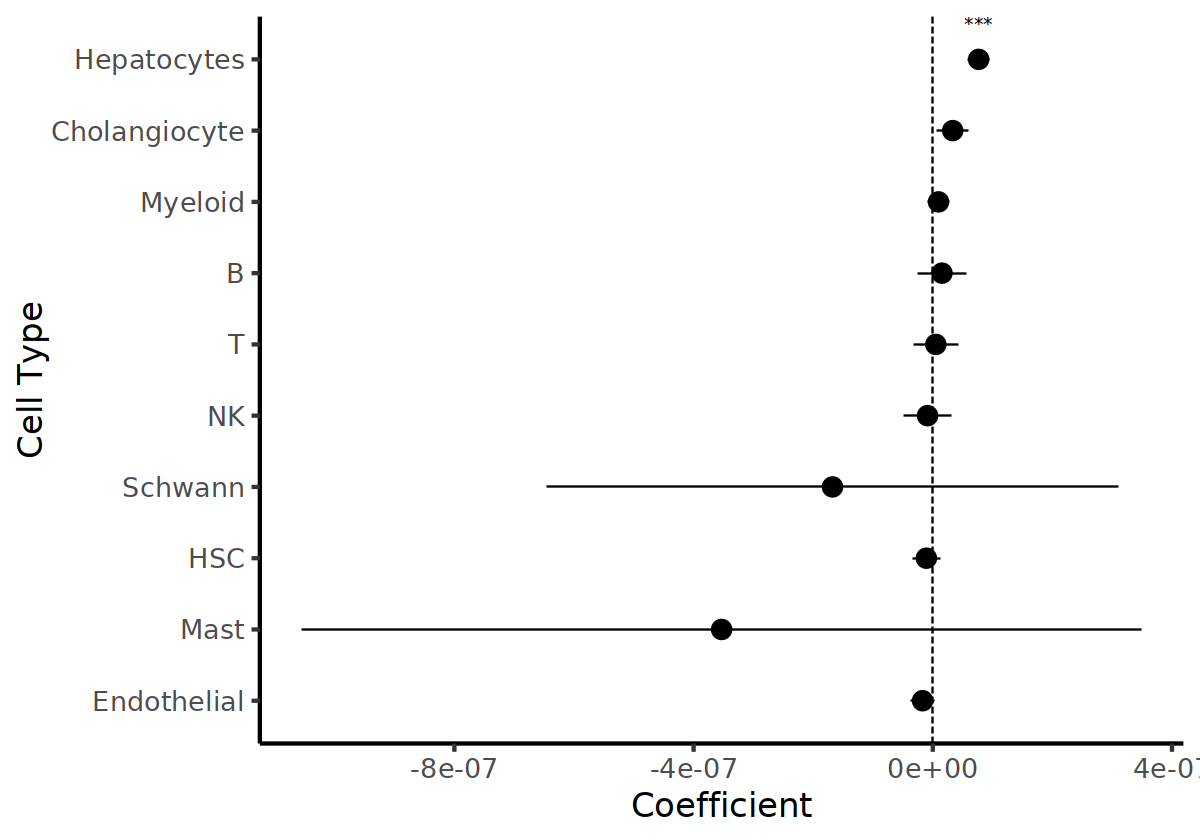

In [10]:
options(repr.plot.width=10)
p1 <- ggplot(h2s.ac, aes(x=Name, y=Coefficient, ymin=Coefficient-Coefficient_std_error, ymax=Coefficient+Coefficient_std_error)) + 
  geom_point(size=5, stroke = 0.5,position=position_dodge(width = 0.5)) +
  geom_linerange(size=0.5) + geom_hline(yintercept=0, linetype = "longdash") +
  scale_x_discrete(name="Cell Type") +
  scale_y_continuous(name="Coefficient") +
  coord_flip() +
  theme_classic(base_size = 20) + geom_text(aes(label = label), nudge_x = 0.5)

p1

#ggsave(plot=p1, filename='/nfs/lab/welison/Liver/Intermediates/40_Map/ALT_LDSC_ct.svg')
#ggsave(plot=p1, filename='/nfs/lab/welison/Liver/Intermediates/40_Map/ALT_LDSC_ct.pdf')
#ggsave(plot=p1, filename='/nfs/lab/welison/Liver/Intermediates/40_Map/ALT_LDSC_ct.tiff')

# H2cts H3K27me3

In [11]:
h2s.me3 <- read.table(paste0(LDSC.res.dir, '/DPT/New.ALT.GWAS.h2cts.ophelia.H3K27me3.cell_type_results.txt'), header=T)
h2s.me3$fdr <- p.adjust(h2s.me3$Coefficient_P_value, method='fdr')
h2s.me3$Name <- factor(h2s.me3$Name, levels = rev(h2s.me3$Name))

h2s.me3

Name,Coefficient,Coefficient_std_error,Coefficient_P_value,fdr
<fct>,<dbl>,<dbl>,<dbl>,<dbl>
Hepatocytes,8.823921e-08,2.658247e-08,0.0004509729,0.004509729
Cholangiocyte,4.500556e-08,3.053409e-08,0.0702482535,0.351241267
Schwann,6.305832e-07,5.563425e-07,0.1285138561,0.428379520
Mast,8.625277e-08,5.877201e-07,0.4416614289,0.766677740
HSC,-4.705954e-09,2.551192e-08,0.5731740760,0.766677740
Myeloid,-5.671689e-09,2.235301e-08,0.6001489422,0.766677740
NK,-1.179859e-08,4.002999e-08,0.6159052168,0.766677740
B,-1.582217e-08,4.354094e-08,0.6418417215,0.766677740
T,-1.710044e-08,3.448513e-08,0.6900099663,0.766677740


In [12]:
h2s.me3 <- h2s.me3 %>%
    mutate(
        label = case_when(
            fdr > 0.05 ~ "",
            fdr > 0.01 ~ "*",
            fdr > 0.001 ~ "**",
            !is.na(fdr) ~ "***",
            TRUE ~ NA_character_
        )
    )

h2s.me3

Name,Coefficient,Coefficient_std_error,Coefficient_P_value,fdr,label
<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
Hepatocytes,8.823921e-08,2.658247e-08,0.0004509729,0.004509729,**
Cholangiocyte,4.500556e-08,3.053409e-08,0.0702482535,0.351241267,
Schwann,6.305832e-07,5.563425e-07,0.1285138561,0.428379520,
Mast,8.625277e-08,5.877201e-07,0.4416614289,0.766677740,
HSC,-4.705954e-09,2.551192e-08,0.5731740760,0.766677740,
Myeloid,-5.671689e-09,2.235301e-08,0.6001489422,0.766677740,
NK,-1.179859e-08,4.002999e-08,0.6159052168,0.766677740,
B,-1.582217e-08,4.354094e-08,0.6418417215,0.766677740,
T,-1.710044e-08,3.448513e-08,0.6900099663,0.766677740,


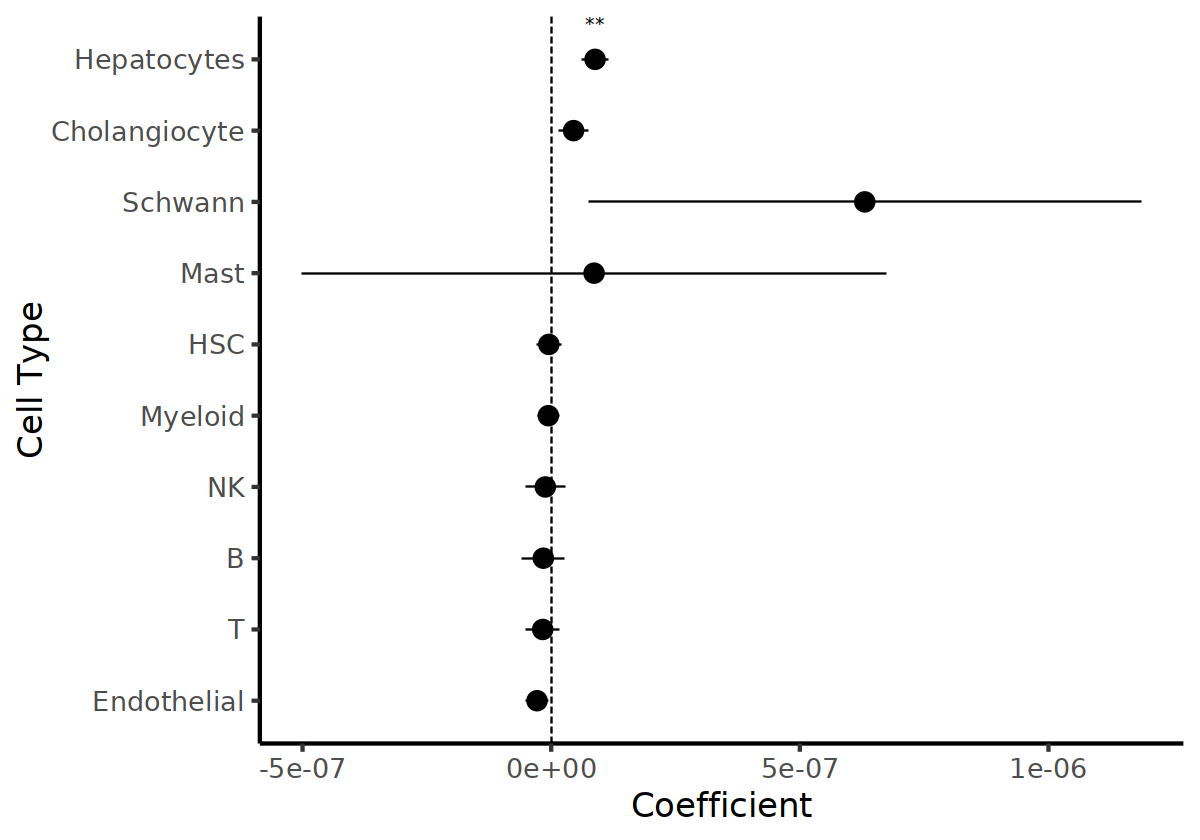

In [13]:
options(repr.plot.width=10)
p1 <- ggplot(h2s.me3, aes(x=Name, y=Coefficient, ymin=Coefficient-Coefficient_std_error, ymax=Coefficient+Coefficient_std_error)) + 
  geom_point(size=5, stroke = 0.5,position=position_dodge(width = 0.5)) +
  geom_linerange(size=0.5) + geom_hline(yintercept=0, linetype = "longdash") +
  scale_x_discrete(name="Cell Type") +
  scale_y_continuous(name="Coefficient") +
  coord_flip() +
  theme_classic(base_size = 20) + geom_text(aes(label = label), nudge_x = 0.5)

p1

#ggsave(plot=p1, filename='/nfs/lab/welison/Liver/Intermediates/40_Map/ALT_LDSC_ct.svg')
#ggsave(plot=p1, filename='/nfs/lab/welison/Liver/Intermediates/40_Map/ALT_LDSC_ct.pdf')
#ggsave(plot=p1, filename='/nfs/lab/welison/Liver/Intermediates/40_Map/ALT_LDSC_ct.tiff')

# Combined

In [14]:
h2s.me3$modality <- 'H3K27me3'
h2s.ac$modality <- 'H3K27ac'
h2s.86$modality <- 'ATAC'

h2s.mod <- rbind(rbind(h2s.me3, h2s.ac), h2s.86)
h2s.mod <- filter(h2s.mod, !Name %in% c('Schwann','Mast'))
h2s.mod

Name,Coefficient,Coefficient_std_error,Coefficient_P_value,fdr,label,modality
<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
Hepatocytes,8.823921e-08,2.658247e-08,0.0004509729,0.004509729,**,H3K27me3
Cholangiocyte,4.500556e-08,3.053409e-08,0.0702482535,0.351241267,,H3K27me3
HSC,-4.705954e-09,2.551192e-08,0.5731740760,0.766677740,,H3K27me3
Myeloid,-5.671689e-09,2.235301e-08,0.6001489422,0.766677740,,H3K27me3
NK,-1.179859e-08,4.002999e-08,0.6159052168,0.766677740,,H3K27me3
B,-1.582217e-08,4.354094e-08,0.6418417215,0.766677740,,H3K27me3
T,-1.710044e-08,3.448513e-08,0.6900099663,0.766677740,,H3K27me3
Endothelial,-2.848342e-08,2.308602e-08,0.8913604030,0.891360403,,H3K27me3
Hepatocytes,7.673432e-08,1.874100e-08,0.0000211574,0.000211574,***,H3K27ac


In [15]:
h2s.mod <- h2s.mod %>%
    mutate(
        label = case_when(
            fdr > 0.1 ~ "",
            fdr > 0.01 ~ "*",
            fdr > 0.001 ~ "**",
            !is.na(fdr) ~ "***",
            TRUE ~ NA_character_
        )
    )

h2s.mod

Name,Coefficient,Coefficient_std_error,Coefficient_P_value,fdr,label,modality
<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
Hepatocytes,8.823921e-08,2.658247e-08,0.0004509729,0.004509729,**,H3K27me3
Cholangiocyte,4.500556e-08,3.053409e-08,0.0702482535,0.351241267,,H3K27me3
HSC,-4.705954e-09,2.551192e-08,0.5731740760,0.766677740,,H3K27me3
Myeloid,-5.671689e-09,2.235301e-08,0.6001489422,0.766677740,,H3K27me3
NK,-1.179859e-08,4.002999e-08,0.6159052168,0.766677740,,H3K27me3
B,-1.582217e-08,4.354094e-08,0.6418417215,0.766677740,,H3K27me3
T,-1.710044e-08,3.448513e-08,0.6900099663,0.766677740,,H3K27me3
Endothelial,-2.848342e-08,2.308602e-08,0.8913604030,0.891360403,,H3K27me3
Hepatocytes,7.673432e-08,1.874100e-08,0.0000211574,0.000211574,***,H3K27ac


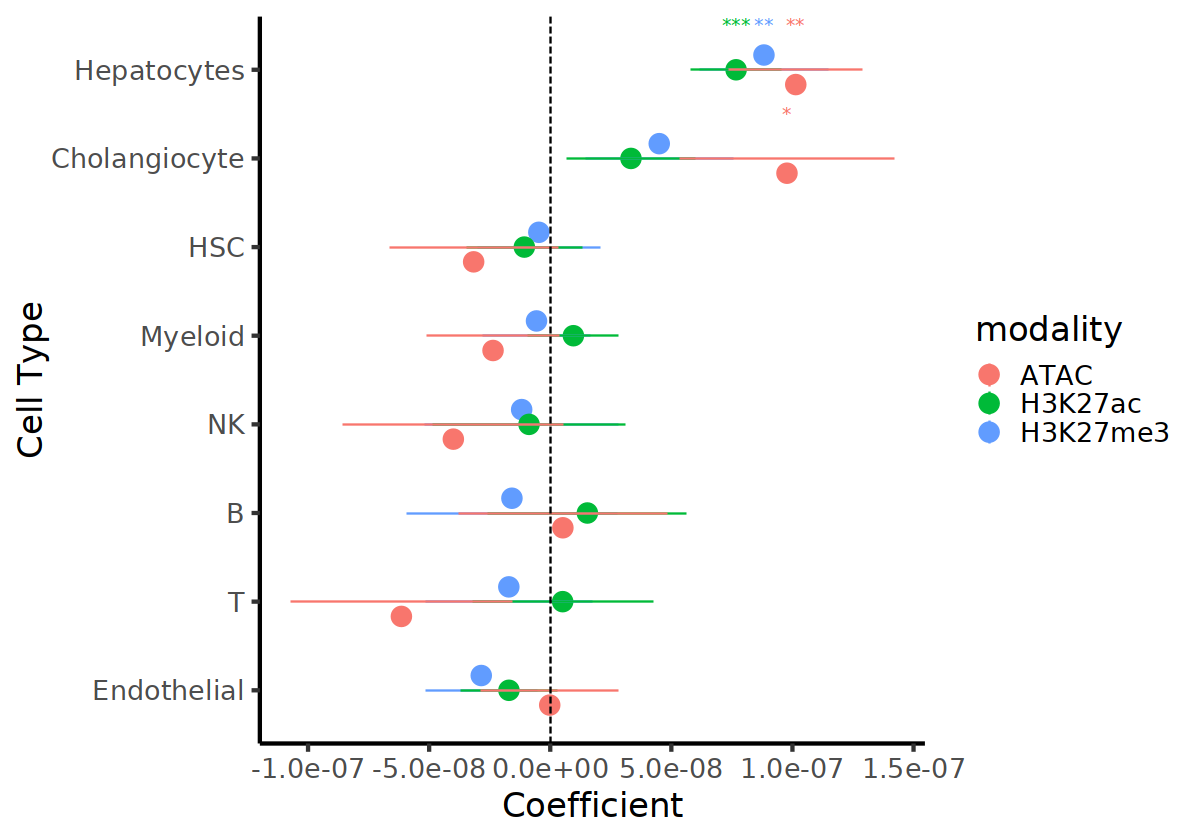

In [16]:
options(repr.plot.width=10)
p1 <- ggplot(h2s.mod, aes(x=Name, y=Coefficient, ymin=Coefficient-Coefficient_std_error, ymax=Coefficient+Coefficient_std_error, color=modality)) + 
  geom_point(size=5, stroke = 0.5,position=position_dodge(width = 0.5)) +
  geom_linerange(size=0.5) + geom_hline(yintercept=0, linetype = "longdash") +
  scale_x_discrete(name="Cell Type") +
  scale_y_continuous(name="Coefficient") +
  coord_flip() +
  theme_classic(base_size = 20) + geom_text(aes(label = label), nudge_x = 0.5) 

p1

#ggsave(plot=p1, filename='/nfs/lab/welison/Liver/Intermediates/40_Map/ALT_LDSC_ct.svg')
#ggsave(plot=p1, filename='/nfs/lab/welison/Liver/Intermediates/40_Map/ALT_LDSC_ct.pdf')
#ggsave(plot=p1, filename='/nfs/lab/welison/Liver/Intermediates/40_Map/ALT_LDSC_ct.tiff')

In [17]:
library(nationalparkcolors)

Saving 10 x 6.67 in image
Saving 10 x 6.67 in image


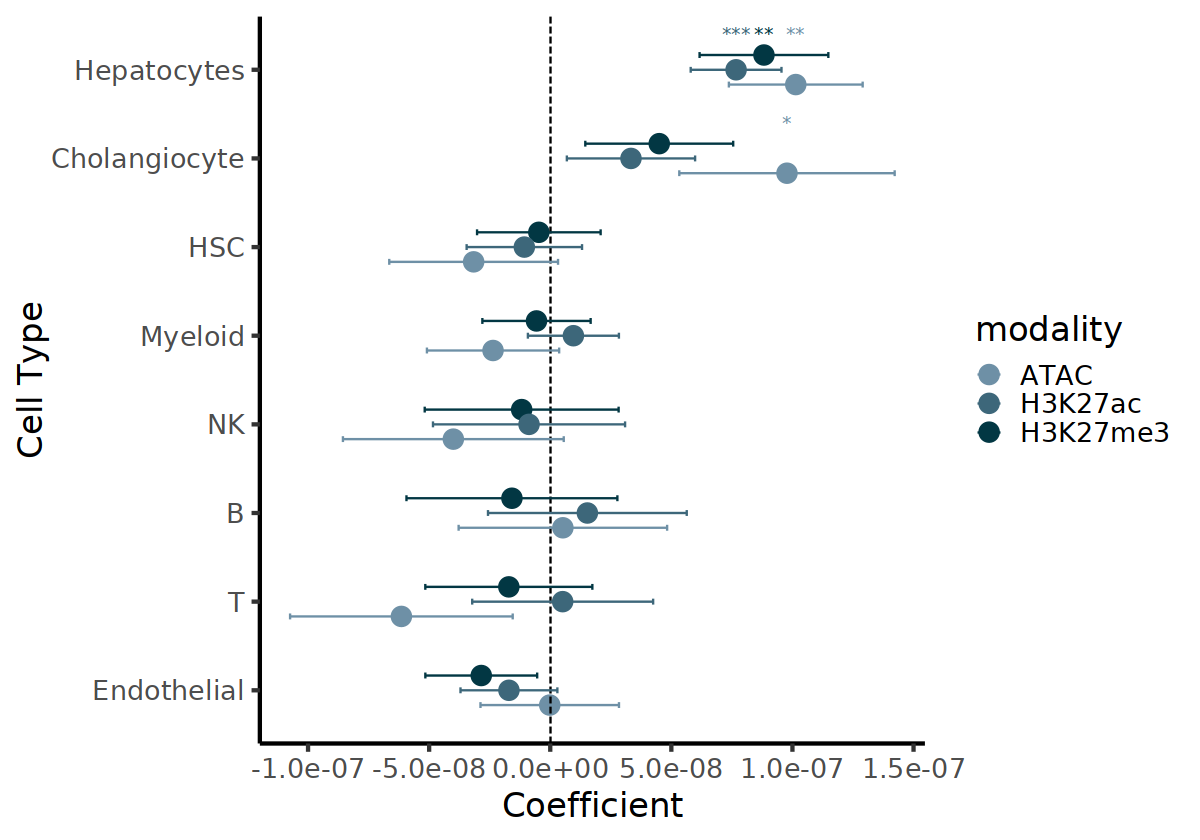

In [18]:
options(repr.plot.width=10)
p1 <- ggplot(h2s.mod, aes(x=Name, y=Coefficient, color=modality)) + 
  geom_point(size=5, stroke = 0.5,position=position_dodge(width = 0.5)) +
  geom_hline(yintercept=0, linetype = "longdash") +
  scale_x_discrete(name="Cell Type") +
  scale_y_continuous(name="Coefficient") +
  coord_flip() +
  theme_classic(base_size = 20) + geom_text(aes(label = label), nudge_x = 0.4) + 
  geom_errorbar(aes(ymin=Coefficient-Coefficient_std_error, ymax=Coefficient+Coefficient_std_error), width=.2,
                 position=position_dodge(.5)) +
  scale_color_manual(values=colorRampPalette(park_palette("Acadia")[c(5,4,2)])(8)[c(3,5,8)])

p1

ggsave(plot=p1, filename='/nfs/lab/tscc/welison/FNIH.Liver/LDSC/ALT_LDSC_ct.pdf', width=10)
ggsave(plot=p1, filename='/nfs/lab/tscc/welison/FNIH.Liver/LDSC/ALT_LDSC_ct.tiff', width=10)

# Subtypes

In [19]:
paste0(LDSC.res.dir, 'subtypes/NAFLD.EUR.MVP.2021.subtypes.cell_type_results.txt')

[1] "/nfs/lab/tscc/welison/FNIH.Liver/LDSC/subtypes/NAFLD.EUR.MVP.2021.subtypes.cell_type_results.txt"

In [20]:
h2s.sub <- read.table(paste0(LDSC.res.dir, 'subtypes/NAFLD.EUR.MVP.2021.subtypes.cell_type_results.txt'), header=T)
h2s.sub$fdr <- p.adjust(h2s.sub$Coefficient_P_value, method='fdr')
h2s.sub$Name <- factor(h2s.sub$Name, levels = rev(h2s.sub$Name))

h2s.sub

Name,Coefficient,Coefficient_std_error,Coefficient_P_value,fdr
<fct>,<dbl>,<dbl>,<dbl>,<dbl>
Hepatocytes.Senescent,1.542170e-07,3.064785e-08,2.428195e-07,2.973259e-06
Hepatocytes.Stress,2.194130e-07,4.378351e-08,2.702963e-07,2.973259e-06
Hepatocytes.Zone1,1.377087e-07,2.975336e-08,1.843038e-06,1.351561e-05
Hepatocytes.Zone3,1.257007e-07,2.762082e-08,2.670317e-06,1.468674e-05
Hepatocytes.Zone2,1.071051e-07,2.460329e-08,6.705688e-06,2.950503e-05
Cholangiocyte,1.137771e-07,4.129570e-08,2.932983e-03,1.075427e-02
Vascular.Endothelial,9.475387e-08,4.477725e-08,1.716746e-02,5.395486e-02
Central.Vein.Endothelial,7.754918e-08,5.153089e-08,6.617403e-02,1.819786e-01
Mesenchymal,6.398261e-08,5.103446e-08,1.049730e-01,2.566007e-01


In [21]:
h2s.sub <- h2s.sub %>%
    mutate(
        label = case_when(
            fdr > 0.05 ~ "",
            fdr > 0.01 ~ "*",
            fdr > 0.001 ~ "**",
            !is.na(fdr) ~ "***",
            TRUE ~ NA_character_
        )
    )

h2s.sub <- arrange(h2s.sub, fdr, desc(Coefficient))
h2s.sub$Name <- factor(h2s.sub$Name, levels = rev(h2s.sub$Name))
h2s.sub$Name.color <- as.character(h2s.sub$Name)
h2s.sub

Name,Coefficient,Coefficient_std_error,Coefficient_P_value,fdr,label,Name.color
<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
Hepatocytes.Stress,2.194130e-07,4.378351e-08,2.702963e-07,2.973259e-06,***,Hepatocytes.Stress
Hepatocytes.Senescent,1.542170e-07,3.064785e-08,2.428195e-07,2.973259e-06,***,Hepatocytes.Senescent
Hepatocytes.Zone1,1.377087e-07,2.975336e-08,1.843038e-06,1.351561e-05,***,Hepatocytes.Zone1
Hepatocytes.Zone3,1.257007e-07,2.762082e-08,2.670317e-06,1.468674e-05,***,Hepatocytes.Zone3
Hepatocytes.Zone2,1.071051e-07,2.460329e-08,6.705688e-06,2.950503e-05,***,Hepatocytes.Zone2
Cholangiocyte,1.137771e-07,4.129570e-08,2.932983e-03,1.075427e-02,*,Cholangiocyte
Vascular.Endothelial,9.475387e-08,4.477725e-08,1.716746e-02,5.395486e-02,,Vascular.Endothelial
Central.Vein.Endothelial,7.754918e-08,5.153089e-08,6.617403e-02,1.819786e-01,,Central.Vein.Endothelial
Mesenchymal,6.398261e-08,5.103446e-08,1.049730e-01,2.566007e-01,,Mesenchymal


In [22]:
cellsubtype_colors

NK                           T 
                  "#6A0DAD"                   "#9B59B6" 
     Sinusoidal.Endothelial       Lymphatic.Endothelial 
                  "#D3372E"                   "#FFCCBC" 
   Central.Vein.Endothelial        Vascular.Endothelial 
                  "#E46F69"                   "#B22222" 
                    Kupffer                  Macrophage 
                  "#CC4C02"                   "#FF7F00" 
Lipid.Associated.Macrophage                           B 
                  "#FC8D59"                   "#8A2BE2" 
                     Plasma               Cholangiocyte 
                  "#BA55D3"                   "#FFD92F" 
               Quescent.HSC               Activated.HSC 
                  "#4682B4"                   "#1E90FF" 
                Mesenchymal                        Mast 
                  "#000080"                   "#8B4513" 
                    Schwann           Hepatocytes.Zone1 
                  "#808080"                   "#006D2C" 
          Hepatocytes.Zone2           Hepatocytes.Zone3 
                  "#4DAF4A"                   "#78C679" 
      Hepatocytes.Senescent          Hepatocytes.Stress 
                  "#A6D96A"                   "#D9F0A3"

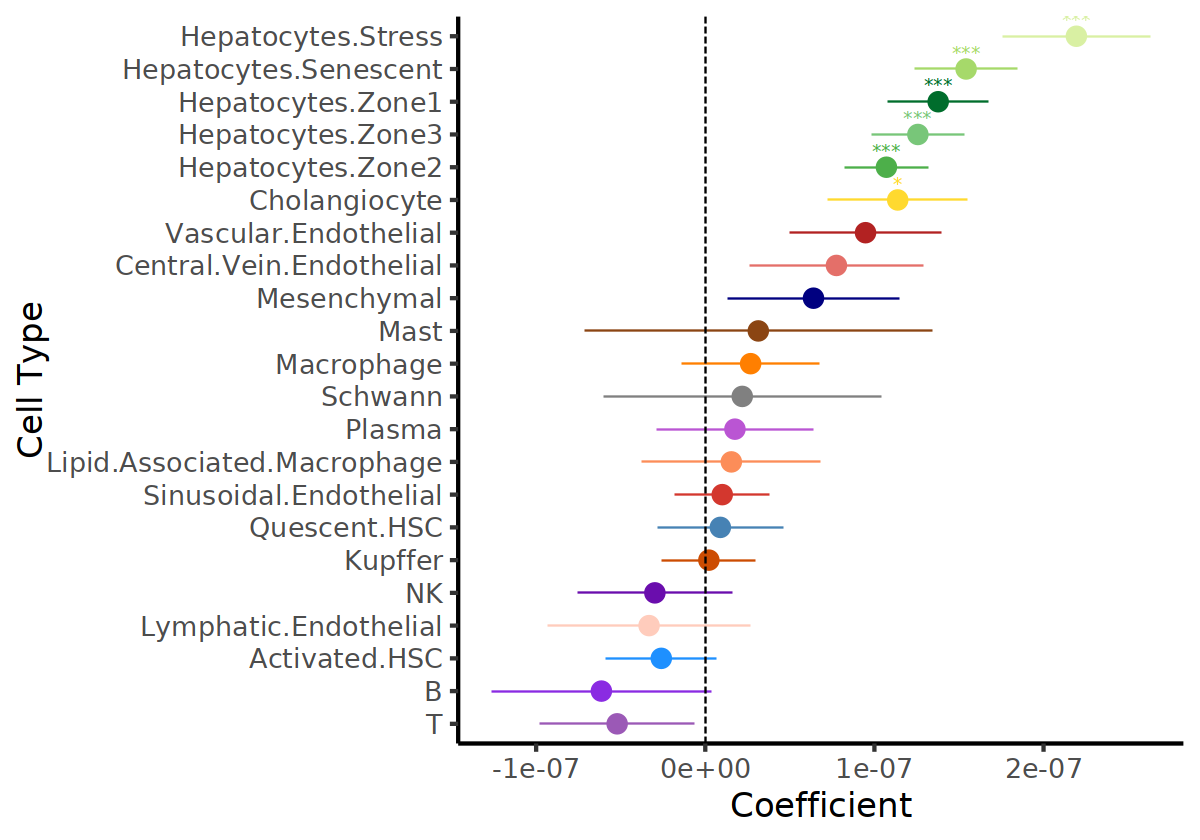

In [23]:
options(repr.plot.width=10)
p1 <- ggplot(h2s.sub, aes(x=Name, y=Coefficient, color=Name.color,
                          ymin=Coefficient-Coefficient_std_error, ymax=Coefficient+Coefficient_std_error)) + 
  geom_point(size=5, stroke = 0.5,position=position_dodge(width = 0.5)) +
  geom_linerange(size=0.5) + geom_hline(yintercept=0, linetype = "longdash") +
  scale_x_discrete(name="Cell Type") +
  scale_y_continuous(name="Coefficient") +coord_flip() + 
  theme_classic(base_size = 20) + theme(legend.position = 'none') + 
  geom_text(aes(label = label), nudge_x = 0.5) + 
  scale_color_manual(values=cellsubtype_colors)

p1

#ggsave(plot=p1, filename='/nfs/lab/welison/Liver/Plots/241221_WE_LDSC_subtype.pdf', width=10)

# States

In [24]:
paste0(LDSC.res.dir, 'states/NAFLD.EUR.MVP.2021.states.cell_type_results.txt')

[1] "/nfs/lab/tscc/welison/FNIH.Liver/LDSC/states/NAFLD.EUR.MVP.2021.states.cell_type_results.txt"

In [25]:
h2s.state <- read.table(paste0(LDSC.res.dir, 'states/NAFLD.EUR.MVP.2021.states.cell_type_results.txt'), header=T)
h2s.state$fdr <- p.adjust(h2s.state$Coefficient_P_value, method='fdr')
h2s.state <- arrange(h2s.state, fdr, desc(Coefficient))
h2s.state$Name <- factor(h2s.state$Name, levels = rev(h2s.state$Name))

h2s.state

Name,Coefficient,Coefficient_std_error,Coefficient_P_value,fdr
<fct>,<dbl>,<dbl>,<dbl>,<dbl>
Hepatocytes.Active,2.827029e-07,6.025312e-08,1.353251e-06,6.766254e-05
Cholangiocyte.Accessible,1.729880e-07,9.716316e-08,3.750632e-02,3.996765e-01
Cholangiocyte.Weak.Signal,1.403792e-07,8.431429e-08,4.796118e-02,3.996765e-01
Myeloid.Active,1.335949e-07,6.271889e-08,1.658337e-02,3.996765e-01
Cholangiocyte.Active,1.317126e-07,7.581483e-08,4.116774e-02,3.996765e-01
T.No.Signal,8.987014e-08,5.195081e-08,4.182332e-02,3.996765e-01
HSC.Weak.Signal,1.208201e-07,9.480228e-08,1.012532e-01,7.232369e-01
Endothelial.Active,6.014676e-08,5.313844e-08,1.288408e-01,8.052548e-01
NK.No.Signal,4.546225e-08,4.415111e-08,1.515762e-01,8.420901e-01


In [26]:
h2s.state <- h2s.state %>%
    mutate(
        label = case_when(
            fdr > 0.05 ~ "",
            fdr > 0.01 ~ "*",
            fdr > 0.001 ~ "**",
            !is.na(fdr) ~ "***",
            TRUE ~ NA_character_
        )
    )

h2s.state$ct <- str_split(h2s.state$Name, '\\.', simplify=T)[,1]
h2s.state <- mutate(h2s.state, state = str_remove(Name, '[:alpha:]*\\.'))
h2s.state$state <- factor(h2s.state$state, levels=rev(c('Active','Accessible','Weak.Signal','No.Signal','Repressive')))

h2s.state

Name,Coefficient,Coefficient_std_error,Coefficient_P_value,fdr,label,ct,state
<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<fct>
Hepatocytes.Active,2.827029e-07,6.025312e-08,1.353251e-06,6.766254e-05,***,Hepatocytes,Active
Cholangiocyte.Accessible,1.729880e-07,9.716316e-08,3.750632e-02,3.996765e-01,,Cholangiocyte,Accessible
Cholangiocyte.Weak.Signal,1.403792e-07,8.431429e-08,4.796118e-02,3.996765e-01,,Cholangiocyte,Weak.Signal
Myeloid.Active,1.335949e-07,6.271889e-08,1.658337e-02,3.996765e-01,,Myeloid,Active
Cholangiocyte.Active,1.317126e-07,7.581483e-08,4.116774e-02,3.996765e-01,,Cholangiocyte,Active
T.No.Signal,8.987014e-08,5.195081e-08,4.182332e-02,3.996765e-01,,T,No.Signal
HSC.Weak.Signal,1.208201e-07,9.480228e-08,1.012532e-01,7.232369e-01,,HSC,Weak.Signal
Endothelial.Active,6.014676e-08,5.313844e-08,1.288408e-01,8.052548e-01,,Endothelial,Active
NK.No.Signal,4.546225e-08,4.415111e-08,1.515762e-01,8.420901e-01,,NK,No.Signal


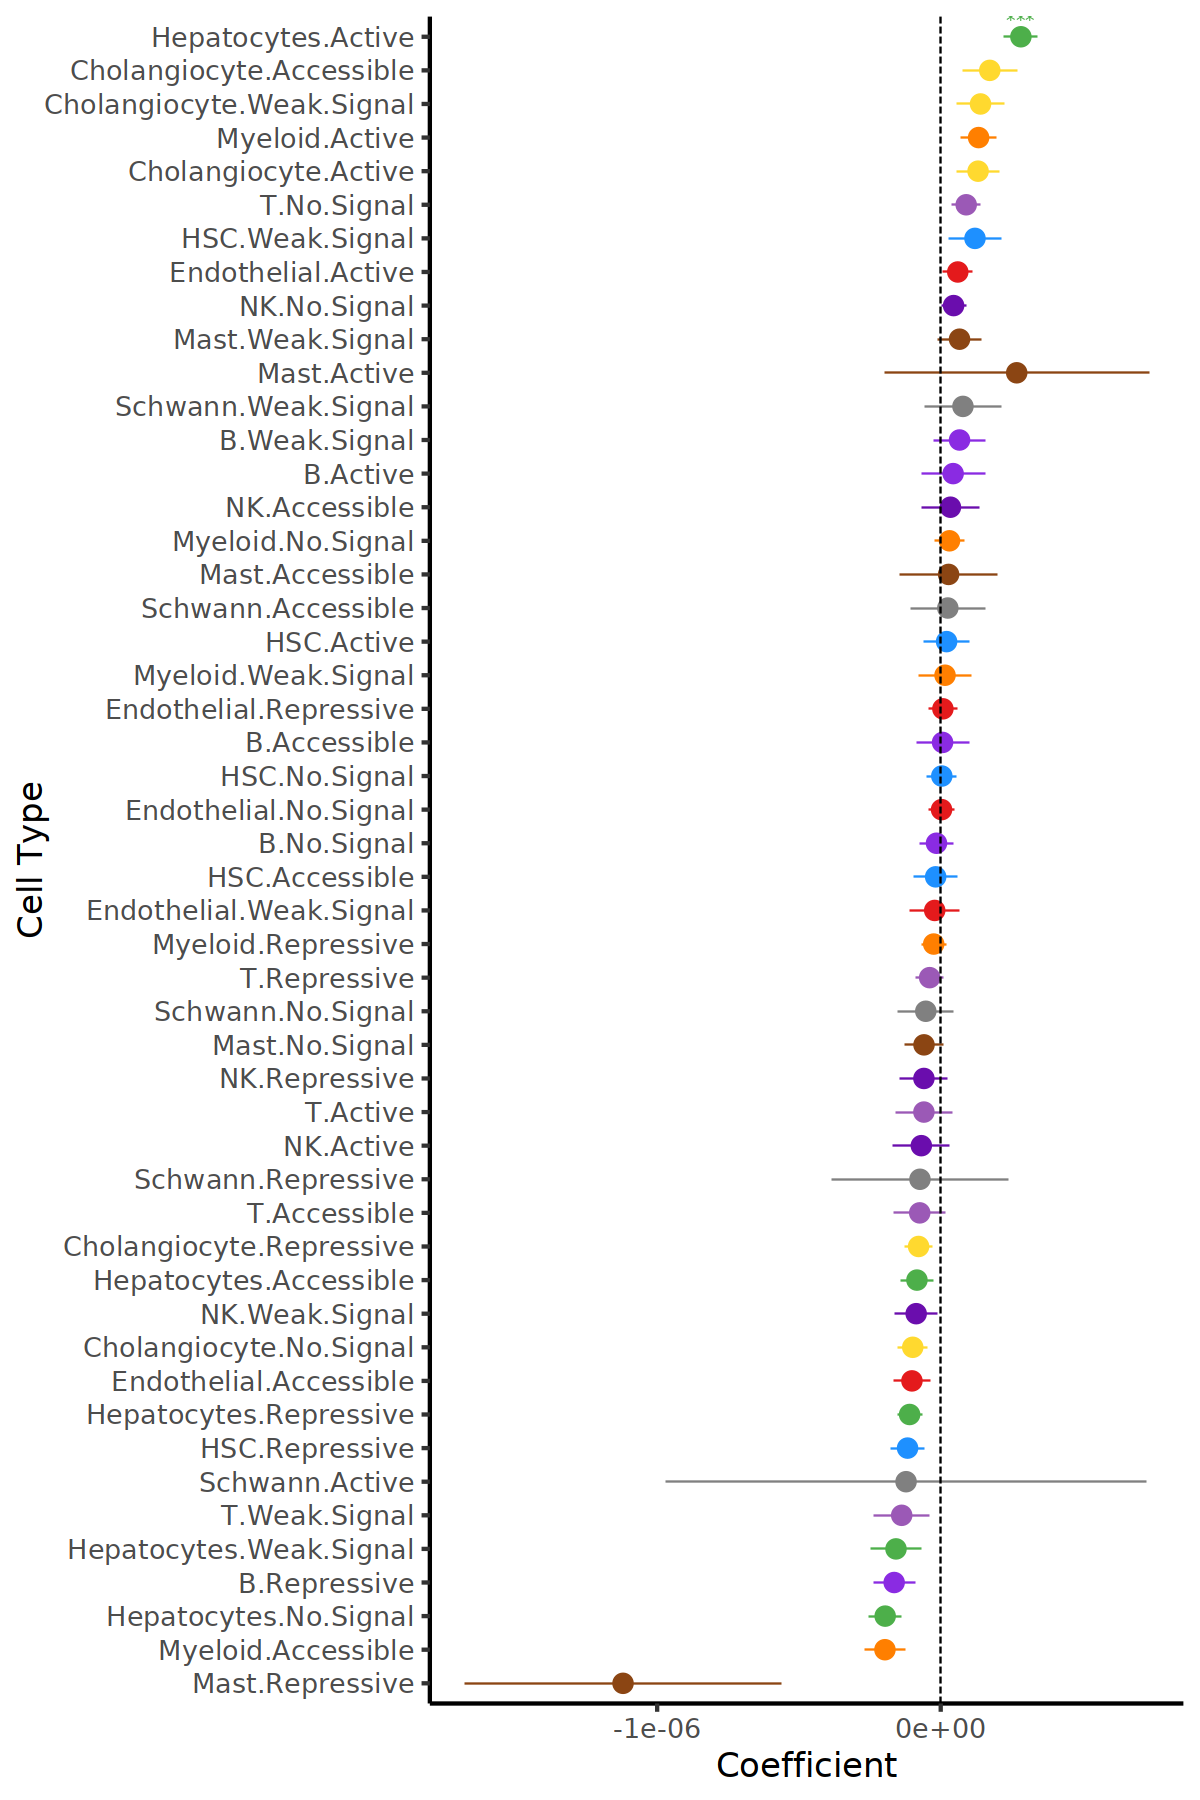

In [27]:
options(repr.plot.width=10, repr.plot.height=15)
p1 <- ggplot(h2s.state, aes(x=Name, y=Coefficient, color=ct,
                          ymin=Coefficient-Coefficient_std_error, ymax=Coefficient+Coefficient_std_error)) + 
  geom_point(size=5, stroke = 0.5,position=position_dodge(width = 0.5)) +
  geom_linerange(size=0.5) + geom_hline(yintercept=0, linetype = "longdash") +
  scale_x_discrete(name="Cell Type") +
  scale_y_continuous(name="Coefficient") +coord_flip() + 
  theme_classic(base_size = 20) + theme(legend.position = 'none') + 
  geom_text(aes(label = label), nudge_x = 0.5) + 
  scale_color_manual(values=celltype_colors)

p1

#ggsave(plot=p1, filename='/nfs/lab/welison/Liver/Plots/241221_WE_LDSC_states.pdf', width=10)

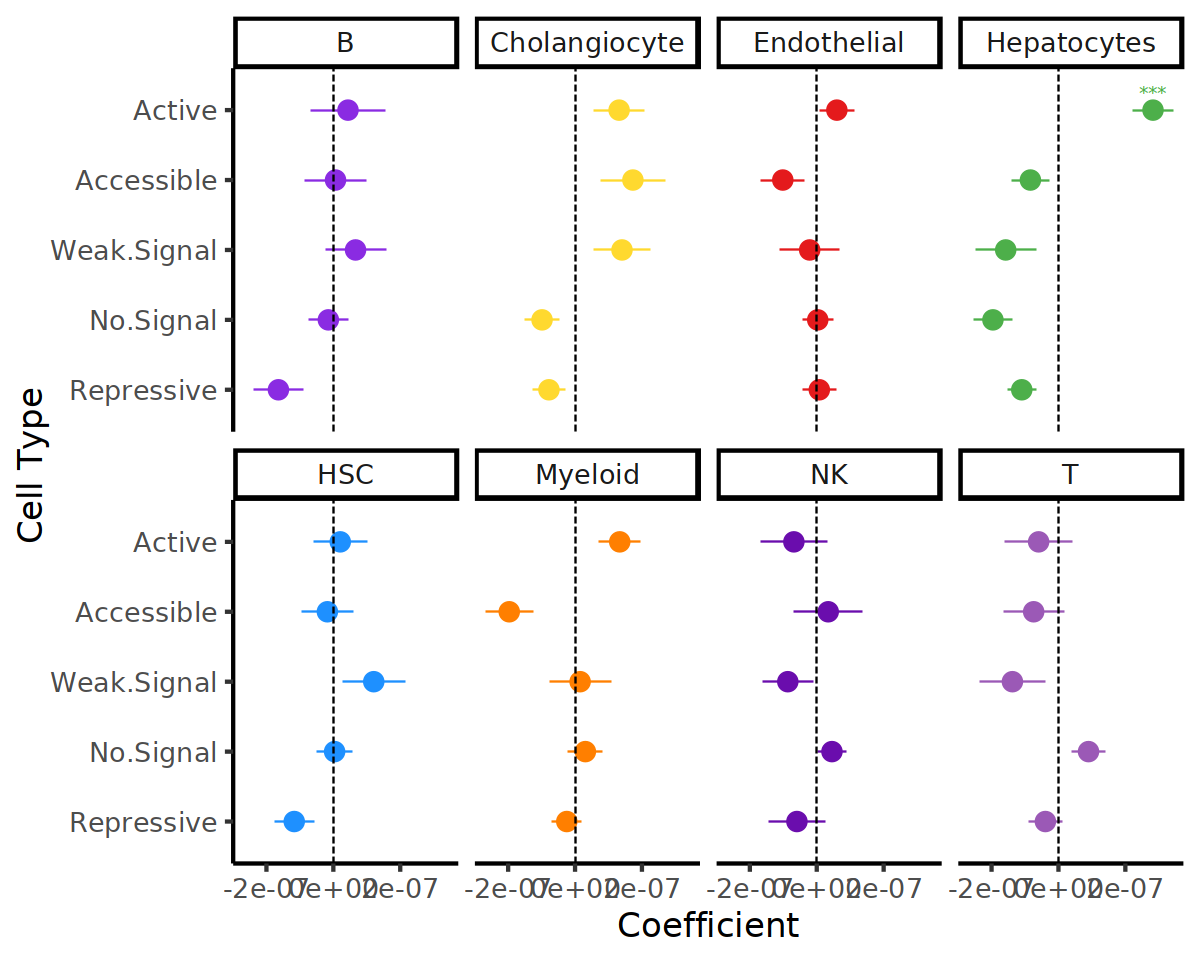

In [28]:
options(repr.plot.width=10, repr.plot.height=8)

p1 <- filter(h2s.state, !ct %in% c('Mast','Schwann')) %>%
        ggplot(aes(x=state, y=Coefficient, color=ct,
                          ymin=Coefficient-Coefficient_std_error, ymax=Coefficient+Coefficient_std_error)) + 
  geom_point(size=5, stroke = 0.5,position=position_dodge(width = 0.5)) +
  geom_linerange(size=0.5) + geom_hline(yintercept=0, linetype = "longdash") +
  scale_x_discrete(name="Cell Type") +
  scale_y_continuous(name="Coefficient") +coord_flip() + 
  theme_classic(base_size = 20) + theme(legend.position = 'none') + 
  geom_text(aes(label = label), nudge_x = 0.25) + 
  scale_color_manual(values=celltype_colors) +
  facet_wrap(. ~ ct, ncol = 4)

p1

#ggsave(plot=p1, filename='/nfs/lab/welison/Liver/Plots/241221_WE_LDSC_states.pdf', width=10, height=8)

In [34]:
h2s.state
h2s.ac

Name,Coefficient,Coefficient_std_error,Coefficient_P_value,fdr,label,ct,state
<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<fct>
Hepatocytes.Active,2.827029e-07,6.025312e-08,1.353251e-06,6.766254e-05,***,Hepatocytes,Active
Cholangiocyte.Accessible,1.729880e-07,9.716316e-08,3.750632e-02,3.996765e-01,,Cholangiocyte,Accessible
Cholangiocyte.Weak.Signal,1.403792e-07,8.431429e-08,4.796118e-02,3.996765e-01,,Cholangiocyte,Weak.Signal
Myeloid.Active,1.335949e-07,6.271889e-08,1.658337e-02,3.996765e-01,,Myeloid,Active
Cholangiocyte.Active,1.317126e-07,7.581483e-08,4.116774e-02,3.996765e-01,,Cholangiocyte,Active
T.No.Signal,8.987014e-08,5.195081e-08,4.182332e-02,3.996765e-01,,T,No.Signal
HSC.Weak.Signal,1.208201e-07,9.480228e-08,1.012532e-01,7.232369e-01,,HSC,Weak.Signal
Endothelial.Active,6.014676e-08,5.313844e-08,1.288408e-01,8.052548e-01,,Endothelial,Active
NK.No.Signal,4.546225e-08,4.415111e-08,1.515762e-01,8.420901e-01,,NK,No.Signal


Name,Coefficient,Coefficient_std_error,Coefficient_P_value,fdr,label,modality
<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
Hepatocytes,7.673432e-08,1.874100e-08,0.0000211574,0.000211574,***,H3K27ac
Cholangiocyte,3.333356e-08,2.647586e-08,0.1040120799,0.520060399,,H3K27ac
Myeloid,9.562158e-09,1.879121e-08,0.3054239564,0.769471393,,H3K27ac
B,1.532986e-08,4.103300e-08,0.3543516106,0.769471393,,H3K27ac
T,5.131179e-09,3.735376e-08,0.4453703098,0.769471393,,H3K27ac
NK,-8.758972e-09,3.965988e-08,0.5873962376,0.769471393,,H3K27ac
Schwann,-1.676971e-07,4.785045e-07,0.6370035740,0.769471393,,H3K27ac
HSC,-1.069678e-08,2.382440e-08,0.6732784067,0.769471393,,H3K27ac
Mast,-3.531303e-07,7.020229e-07,0.6925242536,0.769471393,,H3K27ac


In [30]:
h2s.full <- rbind(h2s.86 %>%
        mutate(ct=Name, state='ATAC', group='ATAC'),
    h2s.ac %>%
        mutate(ct=Name, state='H3K27ac', group='H3K27ac')) %>%
    rbind(mutate(h2s.state, group='States')) %>%
    mutate(state=factor(state, levels=rev(c('Active','Accessible','Weak.Signal',
                                            'No.Signal','Repressive','ATAC','H3K27ac'))))
dim(h2s.full)
head(h2s.full)

ERROR: Error in rbind(deparse.level, ...): numbers of columns of arguments do not match


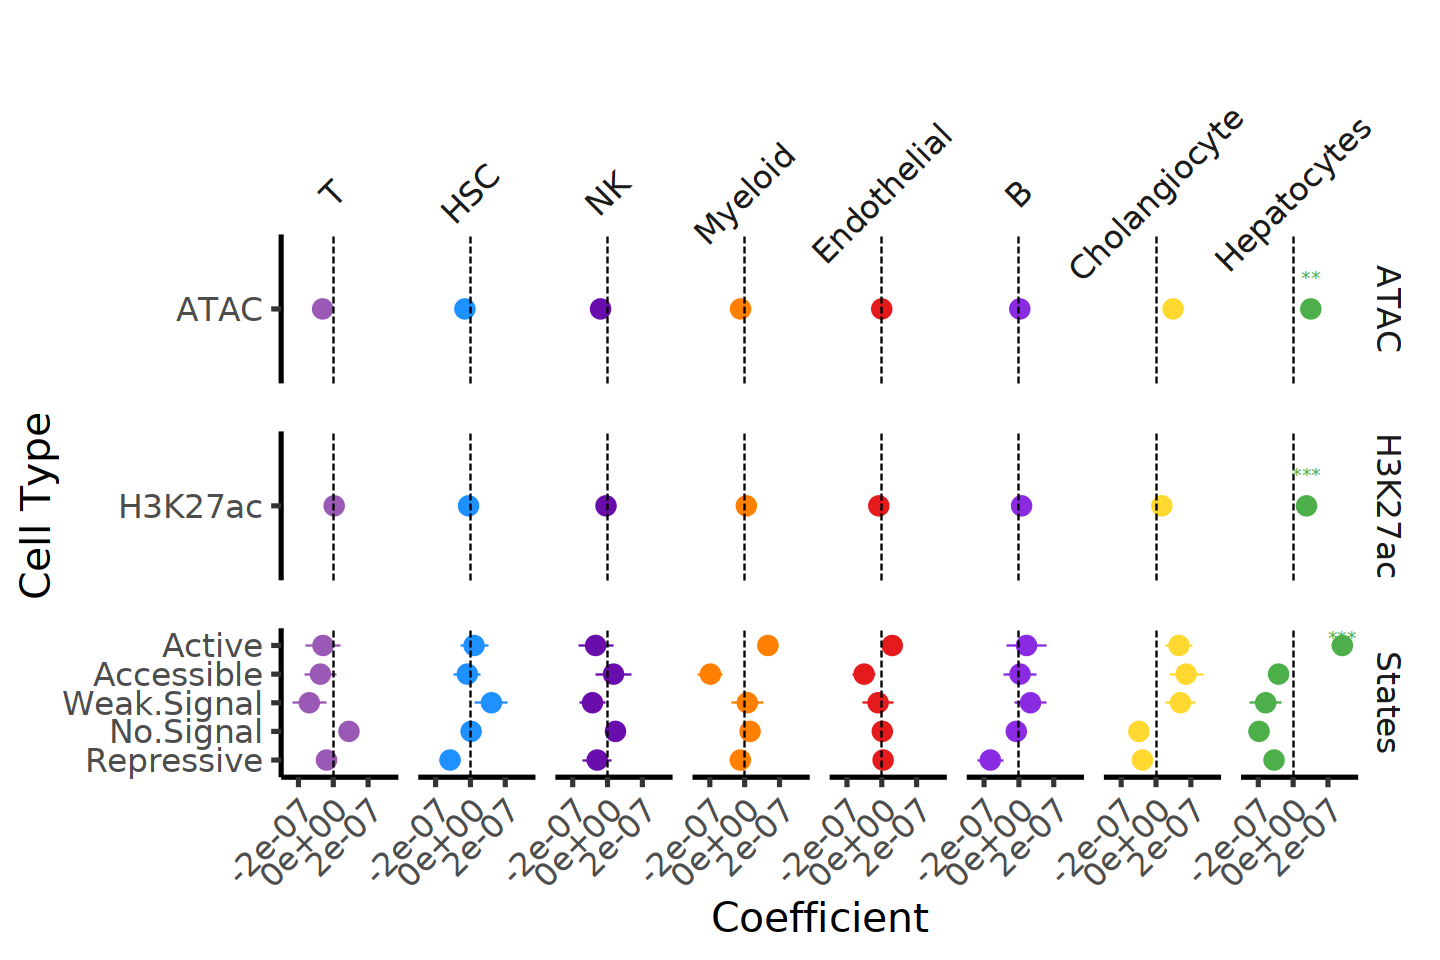

In [64]:
options(repr.plot.width=12, repr.plot.height=8)
p1 <- filter(h2s.full, !ct %in% c('Mast','Schwann')) %>%
        ggplot(aes(x=state, y=Coefficient, color=ct,
                          ymin=Coefficient-Coefficient_std_error, ymax=Coefficient+Coefficient_std_error)) + 
  geom_point(size=5, stroke = 0.5,position=position_dodge(width = 0.5)) +
  geom_linerange(size=0.5) + geom_hline(yintercept=0, linetype = "longdash") +
  scale_x_discrete(name="Cell Type") +
  scale_y_continuous(name="Coefficient") +coord_flip() + 
  theme_classic(base_size = 24) + 
  theme(legend.position = 'none', panel.spacing.y = unit(2, "lines"), strip.background = element_blank(),strip.clip = "off",
        strip.text.x = element_text(angle = 45, vjust=0.1), axis.text.x = element_text(angle = 45, vjust=1, hjust=1)) + 
  geom_text(aes(label = label), nudge_x = 0.25) + 
  scale_color_manual(values=celltype_colors) +
  facet_grid(group ~ ct, scales = 'free_y')

p1
ggsave(plot=p1, filename='/nfs/lab/welison/Liver/Plots/241223_WE_LDSC_states_v2.pdf', width=12, height=8)

In [ ]:
options(repr.plot.width=12, repr.plot.height=8)
p1 <- filter(h2s.full, !ct %in% c('Mast','Schwann')) %>%
        ggplot(aes(x=state, y=Coefficient, color=ct,
                          ymin=Coefficient-Coefficient_std_error, ymax=Coefficient+Coefficient_std_error)) + 
  geom_point(size=5, stroke = 0.5,position=position_dodge(width = 0.5)) +
  geom_linerange(size=0.5) + geom_hline(yintercept=0, linetype = "longdash") +
  scale_x_discrete(name="Cell Type") +
  scale_y_continuous(name="Coefficient") +coord_flip() + 
  theme_classic(base_size = 24) + 
  theme(legend.position = 'none', panel.spacing.y = unit(2, "lines"), strip.background = element_blank(),strip.clip = "off",
        strip.text.x = element_text(angle = 45, vjust=0.1), axis.text.x = element_text(angle = 45, vjust=1, hjust=1)) + 
  geom_text(aes(label = label), nudge_x = 0.25) + 
  scale_color_manual(values=celltype_colors) +
  facet_grid(group ~ ct, scales = 'free_y')

p1
#ggsave(plot=p1, filename='/nfs/lab/welison/Liver/Plots/241223_WE_LDSC_states_v2.pdf', width=12, height=8)

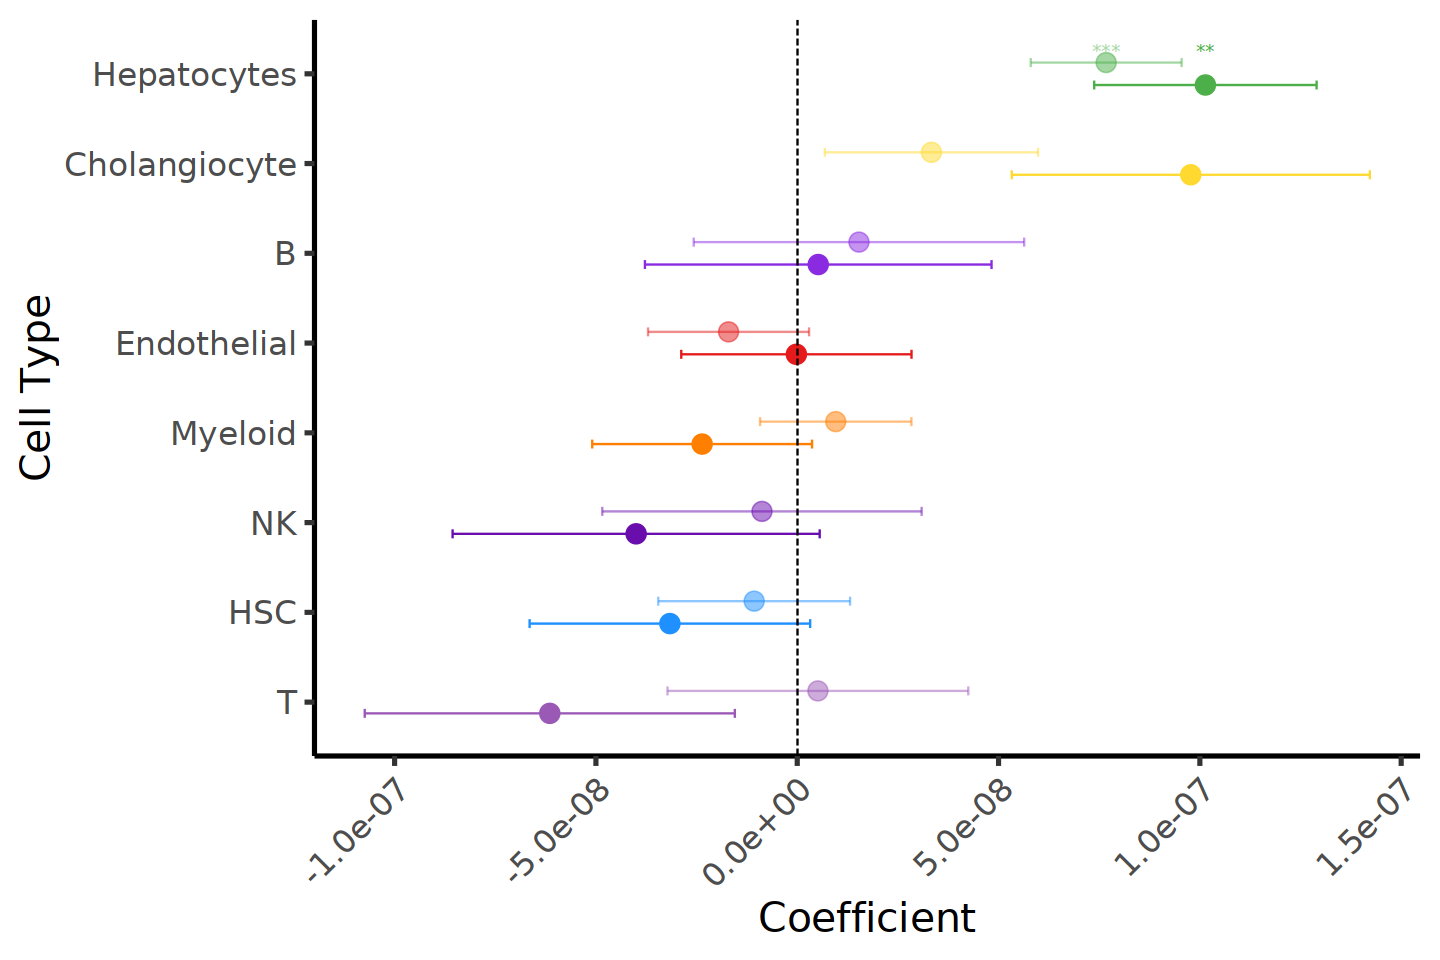

In [75]:
filter(h2s.full, !ct %in% c('Mast','Schwann') & group %in% c('ATAC','H3K27ac')) %>%
        ggplot(aes(x=ct, y=Coefficient, alpha=group, color=ct)) + 
  geom_point(size=5, stroke = 0.5,position=position_dodge(width = 0.5)) +
  geom_errorbar(aes(ymin=Coefficient-Coefficient_std_error, ymax=Coefficient+Coefficient_std_error), width=.2,
                 position=position_dodge(.5)) +
  geom_hline(yintercept=0, linetype = "longdash") +
  scale_x_discrete(name="Cell Type") +
  scale_y_continuous(name="Coefficient") +coord_flip() + 
  theme_classic(base_size = 24) + 
  theme(legend.position = 'none', panel.spacing.y = unit(2, "lines"), strip.background = element_blank(),strip.clip = "off",
        strip.text.x = element_text(angle = 45, vjust=0.1), axis.text.x = element_text(angle = 45, vjust=1, hjust=1)) + 
  geom_text(aes(label = label), nudge_x = 0.25) + 
  scale_color_manual(values=celltype_colors) + scale_alpha_manual(values=c(1,.5))

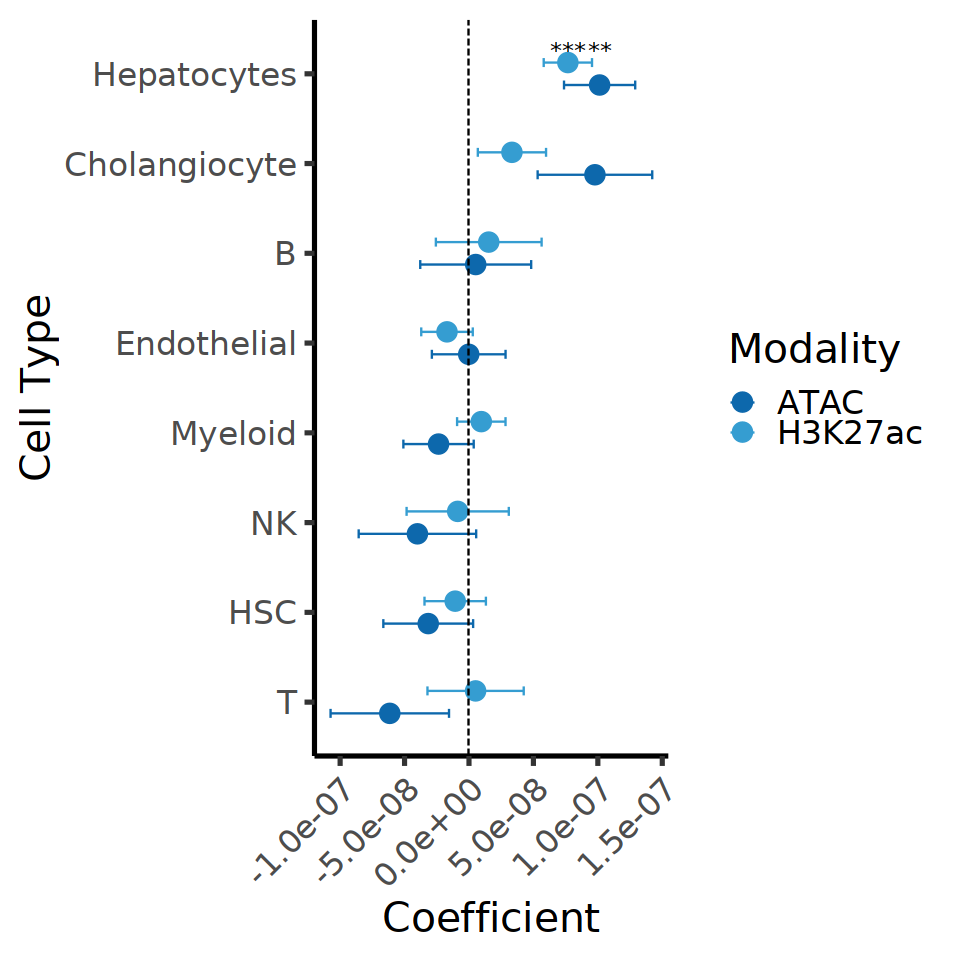

In [111]:
options(repr.plot.width=8, repr.plot.height=8)
p1 <- filter(h2s.full, !ct %in% c('Mast','Schwann') & group %in% c('ATAC','H3K27ac')) %>%
        ggplot(aes(x=ct, y=Coefficient, color=group)) + 
  geom_point(size=5, stroke = 0.5,position=position_dodge(width = 0.5)) +
  geom_errorbar(aes(ymin=Coefficient-Coefficient_std_error, ymax=Coefficient+Coefficient_std_error), width=.2,
                 position=position_dodge(.5)) +
  geom_hline(yintercept=0, linetype = "longdash") +
  scale_x_discrete(name="Cell Type") +
  scale_y_continuous(name="Coefficient") +coord_flip() + 
  theme_classic(base_size = 24) + 
  theme(panel.spacing.y = unit(2, "lines"), strip.background = element_blank(),strip.clip = "off",
        strip.text.x = element_text(angle = 45, vjust=0.1), axis.text.x = element_text(angle = 45, vjust=1, hjust=1)) + 
  geom_text(aes(label = label), nudge_x = 0.25, color='black', size=5) + 
  scale_color_manual(values=c('#0d68ac', '#359dd1')) + labs(color='Modality')

p1
ggsave(plot=p1, filename='/nfs/lab/welison/Liver/Plots/241226_WE_LDSC_states_modalities_v2.pdf', width=8, height=8)

In [116]:
h2s.full$state

[1] ATAC        ATAC        ATAC        ATAC        ATAC        ATAC       
 [7] ATAC        ATAC        ATAC        ATAC        H3K27ac     H3K27ac    
[13] H3K27ac     H3K27ac     H3K27ac     H3K27ac     H3K27ac     H3K27ac    
[19] H3K27ac     H3K27ac     Active      Accessible  Weak.Signal Active     
[25] Active      No.Signal   Weak.Signal Active      No.Signal   Weak.Signal
[31] Active      Weak.Signal Weak.Signal Active      Accessible  No.Signal  
[37] Accessible  Accessible  Active      Weak.Signal Repressive  Accessible 
[43] No.Signal   No.Signal   No.Signal   Accessible  Weak.Signal Repressive 
[49] Repressive  No.Signal   No.Signal   Repressive  Active      Active     
[55] Repressive  Accessible  Repressive  Accessible  Weak.Signal No.Signal  
[61] Accessible  Repressive  Repressive  Active      Weak.Signal Weak.Signal
[67] Repressive  No.Signal   Accessible  Repressive 
Levels: H3K27ac ATAC Repressive No.Signal Weak.Signal Accessible Active

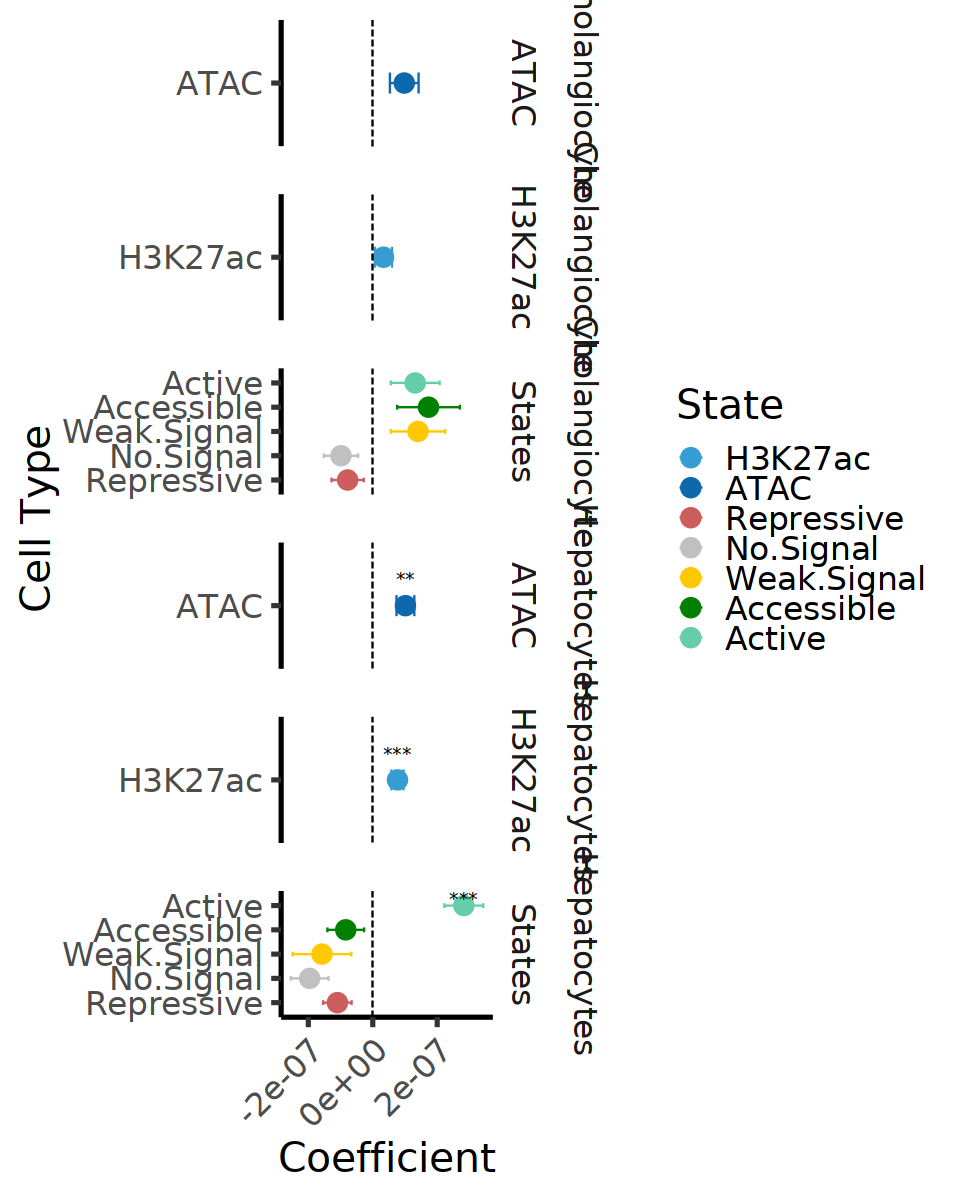

In [117]:
options(repr.plot.width=8, repr.plot.height=10)
p1 <- filter(h2s.full, ct %in% c('Hepatocytes','Cholangiocyte')) %>%
        ggplot(aes(x=state, y=Coefficient, color=state, group=ct)) + 
  geom_point(size=5, stroke = 0.5,position=position_dodge(width = 0.5)) +
  geom_errorbar(aes(ymin=Coefficient-Coefficient_std_error, ymax=Coefficient+Coefficient_std_error), width=.2,
                 position=position_dodge(.5)) + 
  geom_hline(yintercept=0, linetype = "longdash") +
  scale_x_discrete(name="Cell Type") +
  scale_y_continuous(name="Coefficient") +coord_flip() + 
  theme_classic(base_size = 24) + 
  theme(panel.spacing.y = unit(2, "lines"), strip.background = element_blank(),strip.clip = "off",
        strip.text.x = element_text(angle = 45, vjust=0.1), axis.text.x = element_text(angle = 45, vjust=1, hjust=1)) + 
  geom_text(aes(label = label), nudge_x = 0.25, color='black') + 
  scale_color_manual(values=c(ATAC='#0d68ac', H3K27ac='#359dd1', Active='#66cdaa', Accessible='#008000',
                             Weak.Signal='#ffc800',No.Signal='#c0c0c0', Repressive='#cd5c5c')) + labs(color='State') +
  facet_grid(ct + group ~ ., scales = 'free_y')

p1
ggsave(plot=p1, filename='/nfs/lab/welison/Liver/Plots/241226_WE_LDSC_states_cutout_v2.pdf', width=8, height=10)

ERROR: Error in eval(expr, envir, enclos): object 'h2s.full' not found
